In [3]:
import pandas as pd
airbnb = pd.read_csv("data/airbnb.csv")
airbnb.head(5)

,Unnamed: 0,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import seaborn as sns

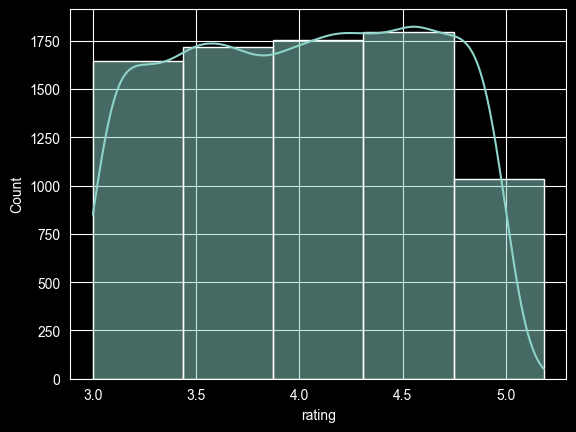

In [34]:
sns.histplot(airbnb['rating'], kde=True, bins = 5)
plt.show()

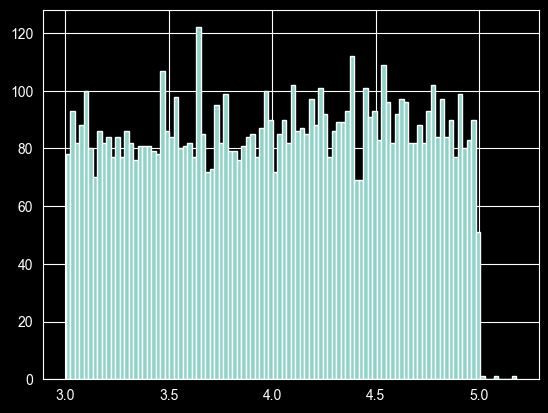

In [32]:
plt.hist(airbnb['rating'], bins=100)
plt.show()

In [12]:
airbnb['price'] = airbnb['price'].astype(str).str.replace('$', '').astype(float)
sol = airbnb.groupby('price')['number_of_stays'].mean()
sol

price
0.0        1.200000
10.0      32.600000
16.0       3.600000
18.0       1.200000
20.0      22.114286
            ...    
4100.0          NaN
4160.0          NaN
5000.0     4.800000
5250.0          NaN
8000.0     1.200000
Name: number_of_stays, Length: 433, dtype: float64

<Axes: xlabel='price_range', ylabel='Count'>

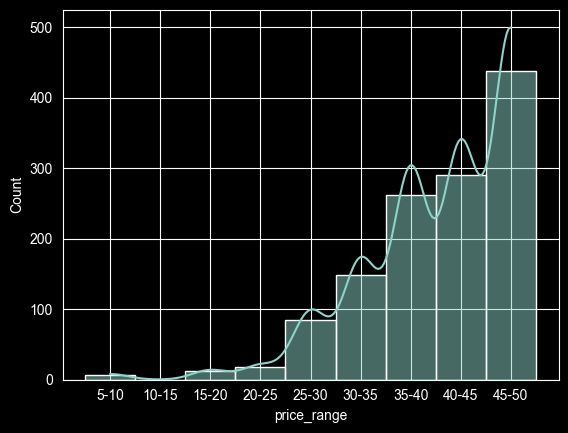

In [16]:
price_val =[0,5,10,15,20,25,30,35,40,45,50]
price_labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50']
airbnb['price_range'] = pd.cut(airbnb['price'], bins=price_val, labels=price_labels)
sns.histplot(airbnb['price_range'], kde=True, alpha=0.5)

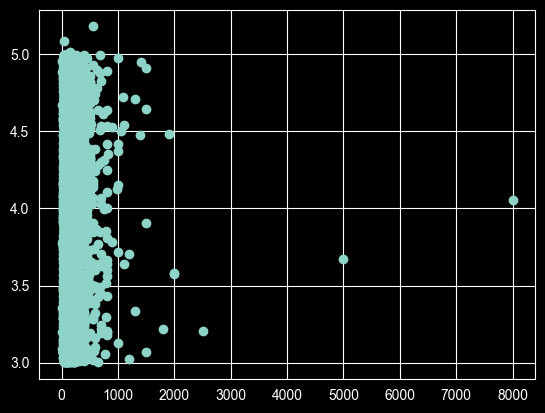

In [18]:
plt.scatter(airbnb['price'], airbnb['rating'])

<Axes: xlabel='price', ylabel='rating'>

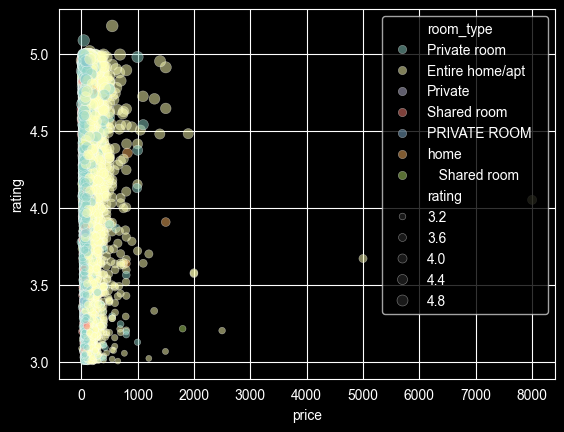

In [30]:
sns.scatterplot(airbnb, x='price', y='rating', alpha=0.5, size='rating', hue='room_type')

<Axes: xlabel='room_type', ylabel='price'>

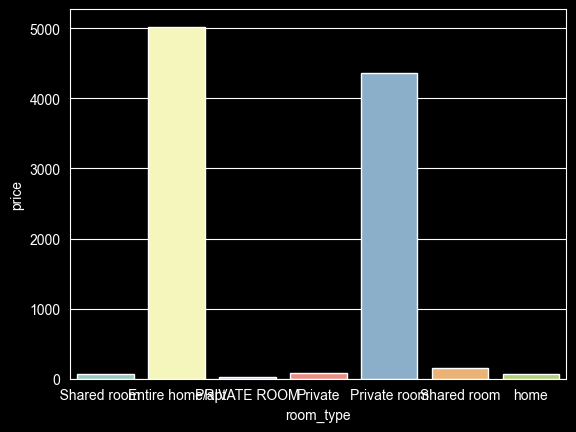

In [54]:
counted = airbnb.groupby('room_type')['price'].count().reset_index()
sns.barplot(data=counted, x='room_type' , y='price' , hue='room_type')

<Axes: xlabel='price', ylabel='rating'>

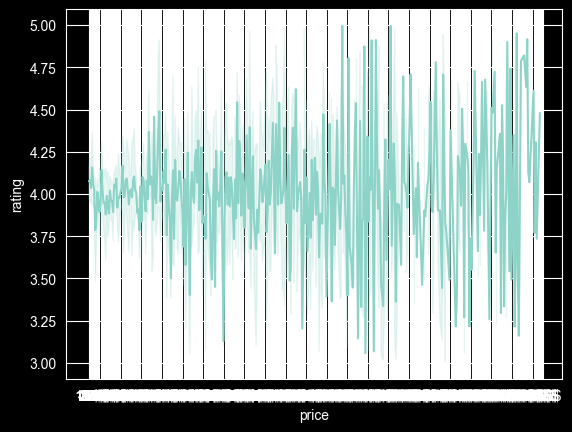

In [55]:
sns.lineplot(data=airbnb, x='price', y='rating')

<Axes: xlabel='number_of_reviews', ylabel='Count'>

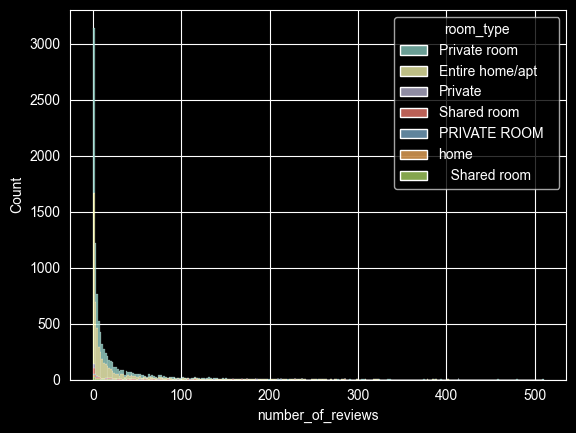

In [59]:
sns.histplot(data=airbnb, x='number_of_reviews', hue='room_type', multiple='stack')

<Axes: xlabel='room_type', ylabel='price'>

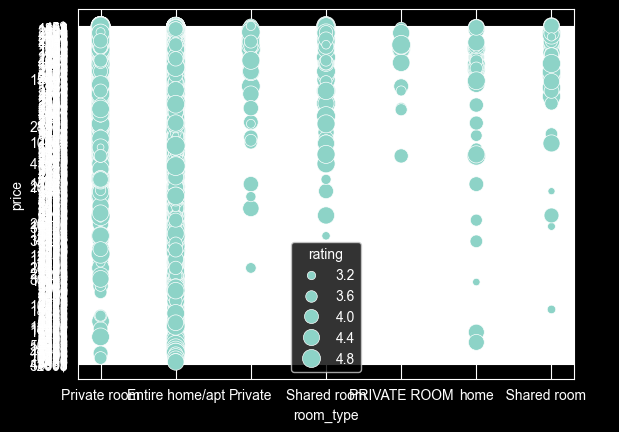

In [60]:
sns.scatterplot(data=airbnb, x='room_type', y='price', size='rating', sizes=(20, 200))

<Axes: xlabel='room_type', ylabel='price'>

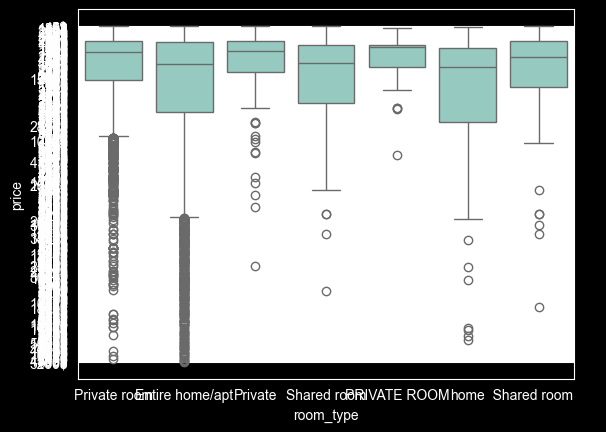

In [61]:
sns.boxplot(data=airbnb, x='room_type', y='price')

In [37]:
mappings = {
    'private room': 'private room',
    'private': 'private room',
    'entire home/apt': 'entire',
    'shared room': 'shared room',
    'shared': 'shared room',
    'home': 'entire'
}


airbnb['room_type'] = airbnb['room_type'].str.lower().str.strip().replace(mappings)

<Axes: xlabel='room_type', ylabel='Count'>

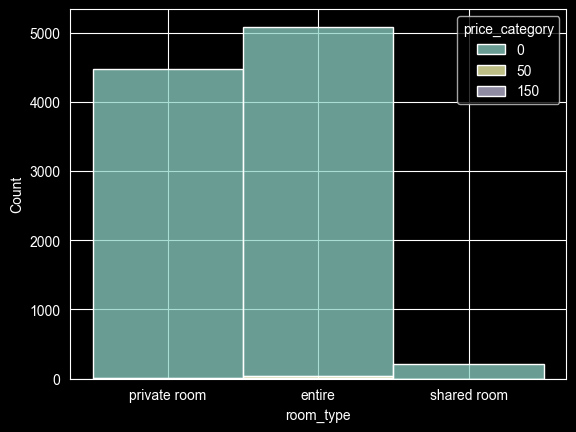

In [38]:
my_price = [0, 1000, 3000, float('inf')]
labels = ['0', '50', '150']
airbnb['price_category'] = pd.cut(airbnb['price'], bins=my_price, labels=labels)

sns.histplot(data=airbnb, x='room_type', hue='price_category', multiple='stack')

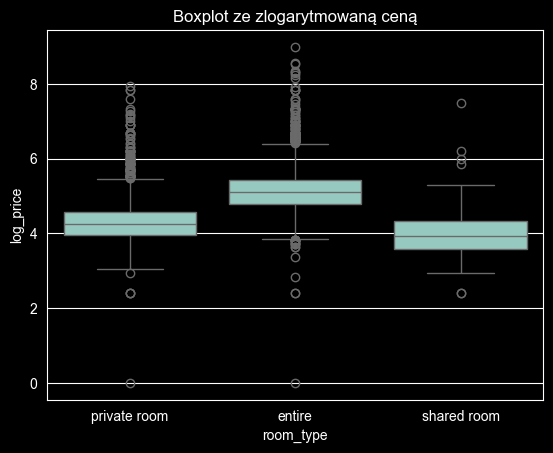

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

airbnb['log_price'] = np.log1p(airbnb['price'])

sns.boxplot(data=airbnb, x='room_type', y='log_price')

plt.title('Boxplot ze zlogarytmowaną ceną')
plt.show()

In [47]:
airbnb.groupby('room_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
entire,5086.0,209.717263,251.258470,0.0,120.0,163.0,229.0,8000.0
private room,4476.0,88.016309,108.986972,0.0,51.0,70.0,95.0,2850.0
shared room,219.0,70.410959,129.253272,10.0,34.5,50.0,75.0,1800.0
